# 📰 Fake News Detection — Comprehensive Model Comparison
### All 17 Model Families · 10 Metrics Each
**Models covered**:  
Classical ML → Logistic Regression, Naive Bayes, SVM (LinearSVC), Random Forest, Extra Trees,  
Gradient Boosting, XGBoost, LightGBM, AdaBoost, Ridge Classifier  
Deep Learning → TextCNN, LSTM, Bidirectional LSTM, GRU, Bidirectional GRU, CNN-LSTM Hybrid, Deep MLP (Word2Vec)  

**Metrics**: Accuracy · Precision · Recall · F1-Score · ROC-AUC · RMSE · MSE · MAE · R² · MAPE(%)


In [1]:
# Install dependencies (run once in Colab / fresh environment)
!pip install -q xgboost lightgbm imbalanced-learn
!pip install -q tensorflow          # for deep-learning section


In [2]:
import re, math, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, mean_squared_error, mean_absolute_error, r2_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.linear_model  import LogisticRegression, RidgeClassifier
from sklearn.naive_bayes   import MultinomialNB
from sklearn.svm           import LinearSVC
from sklearn.ensemble      import (RandomForestClassifier, ExtraTreesClassifier,
                                   GradientBoostingClassifier, AdaBoostClassifier)
import xgboost as xgb

try:
    import lightgbm as lgb
    HAS_LGB = True
    print('LightGBM available ✓')
except ImportError:
    HAS_LGB = False
    print('LightGBM not installed — pip install lightgbm to enable it')

try:
    import tensorflow as tf
    from tensorflow.keras.preprocessing.text import Tokenizer as KerasTok
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tensorflow.keras.models import Sequential, Model
    from tensorflow.keras.layers import (Embedding, LSTM, GRU, Bidirectional,
        Conv1D, Dense, Dropout, GlobalMaxPooling1D, Input, concatenate)
    from tensorflow.keras.callbacks import EarlyStopping
    HAS_TF = True
    print(f'TensorFlow {tf.__version__} available ✓')
except Exception as e:
    HAS_TF = False
    print(f'TensorFlow not available — deep-learning cells will be skipped')

print('All imports done.')


LightGBM available ✓
TensorFlow 2.19.0 available ✓
All imports done.


## 1 · Data Loading & Exploratory Analysis

In [3]:
df = pd.read_csv('/content/news.csv')   # adjust path if needed
df.drop(columns=['Unnamed: 0'], errors='ignore', inplace=True)
df.dropna(subset=['text'], inplace=True)
df.reset_index(drop=True, inplace=True)
print('Shape:', df.shape)
print('Label distribution:')
print(df['label'].value_counts())
df.head(3)


Shape: (6335, 3)
Label distribution:
label
REAL    3171
FAKE    3164
Name: count, dtype: int64


,title,text,label
0,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL


In [4]:
# Feature engineering
df['word_count']   = df['text'].apply(lambda x: len(str(x).split()))
df['char_count']   = df['text'].apply(lambda x: len(str(x)))
df['unique_ratio'] = df['text'].apply(
    lambda x: len(set(str(x).lower().split())) / max(len(str(x).split()), 1))
df['caps_ratio']   = df['text'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)), 1))
print('Feature stats by label:')
df.groupby('label')[['word_count','char_count','unique_ratio','caps_ratio']].mean().round(3)


Feature stats by label:


,word_count,char_count,unique_ratio,caps_ratio
label,,,,
FAKE,679.129,4121.046,0.596,0.043
REAL,873.258,5292.160,0.571,0.031


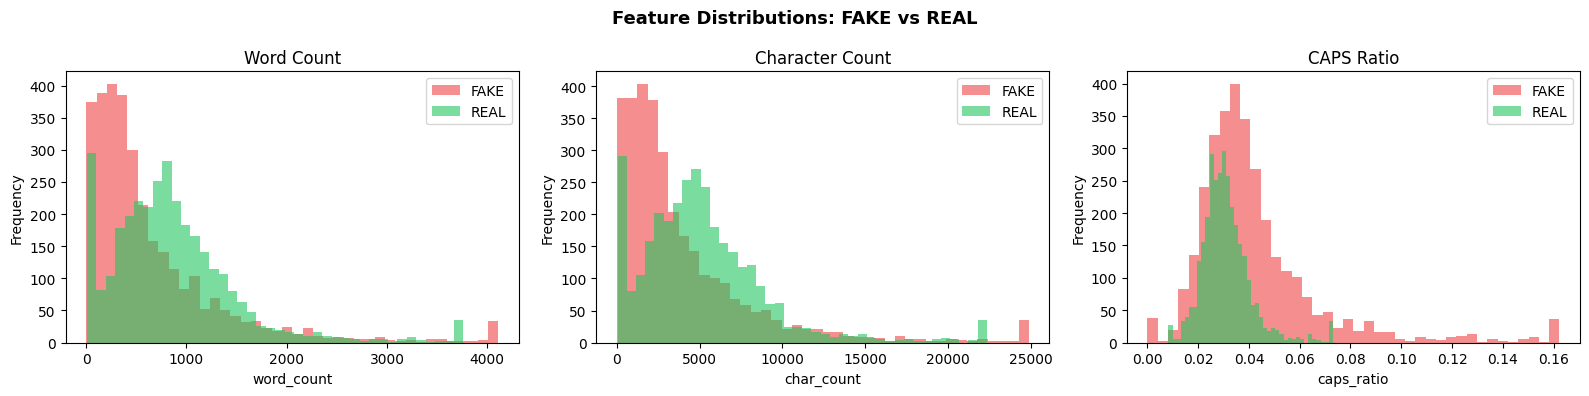

In [5]:
# Distribution plots
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
palette = {'FAKE': '#ef4444', 'REAL': '#22c55e'}
for ax, col, title in zip(axes,
        ['word_count','char_count','caps_ratio'],
        ['Word Count','Character Count','CAPS Ratio']):
    for label, grp in df.groupby('label'):
        grp[col].clip(upper=grp[col].quantile(0.99)).plot.hist(
            ax=ax, alpha=0.6, bins=40, label=label, color=palette[label])
    ax.set_title(title); ax.legend(); ax.set_xlabel(col)
plt.suptitle('Feature Distributions: FAKE vs REAL', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


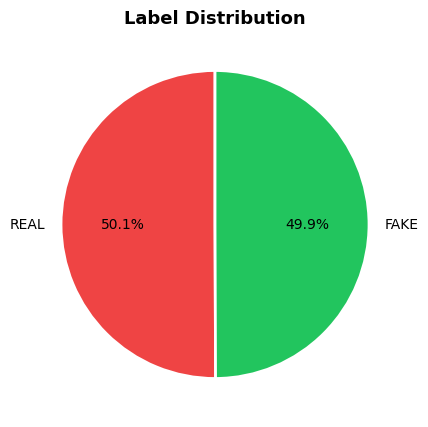

In [6]:
# Label pie chart
counts = df['label'].value_counts()
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(counts, labels=counts.index, autopct='%1.1f%%',
       colors=['#ef4444','#22c55e'], startangle=90,
       wedgeprops=dict(edgecolor='white', linewidth=2))
ax.set_title('Label Distribution', fontsize=13, fontweight='bold')
plt.show()


## 2 · Text Pre-processing & TF-IDF Vectorisation

In [7]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean'] = df['text'].apply(clean_text)
df = df[df['clean'].str.strip() != ''].reset_index(drop=True)

le = LabelEncoder()
y  = le.fit_transform(df['label'])   # FAKE=0, REAL=1
print('Classes:', le.classes_, '-> encoded as [0, 1]')

SEED = 42
tfidf   = TfidfVectorizer(stop_words='english', max_features=10_000, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(df['clean'])
print('TF-IDF matrix shape:', X_tfidf.shape)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_tfidf, y, test_size=0.20, random_state=SEED, stratify=y)
print(f'Train: {X_tr.shape[0]}  |  Test: {X_te.shape[0]}')


Classes: ['FAKE' 'REAL'] -> encoded as [0, 1]
TF-IDF matrix shape: (6298, 10000)
Train: 5038  |  Test: 1260


## 3 · Metrics Helper Function

In [8]:
def mape_score(y_true, y_prob):
    """MAPE on probability outputs, ignoring zero true-label rows."""
    y_true = np.array(y_true, dtype=float)
    y_prob = np.array(y_prob, dtype=float)
    mask = y_true != 0
    if not mask.any():
        return float('nan')
    return float(np.mean(np.abs((y_true[mask] - y_prob[mask]) / y_true[mask])) * 100)

def compute_all_metrics(name, y_true, y_pred, y_prob, elapsed):
    """Return dict of all 10 metrics + model name + train time."""
    mse_val = mean_squared_error(y_true, y_prob)
    return {
        'Model':    name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1-Score':  round(f1_score(y_true, y_pred, zero_division=0), 4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_prob), 4),
        'RMSE':      round(math.sqrt(mse_val), 4),
        'MSE':       round(mse_val, 4),
        'MAE':       round(mean_absolute_error(y_true, y_prob), 4),
        'R2':        round(r2_score(y_true, y_prob), 4),
        'MAPE(%)':   round(mape_score(y_true, y_prob), 2),
        'Time(s)':   round(elapsed, 2),
    }

print('Metrics helper defined ✓')


Metrics helper defined ✓


## 4 · Classical ML Models
Includes: Logistic Regression, Naive Bayes, SVM (LinearSVC), Random Forest,  
Extra Trees, Gradient Boosting, XGBoost, AdaBoost, Ridge Classifier, LightGBM

In [9]:
classical_models = {
    'Logistic Regression':
        LogisticRegression(max_iter=1000, C=1.0, random_state=SEED),
    'Naive Bayes':
        MultinomialNB(alpha=0.1),
    'SVM (LinearSVC)':
        CalibratedClassifierCV(LinearSVC(max_iter=2000, C=1.0, random_state=SEED)),
    'Random Forest':
        RandomForestClassifier(n_estimators=200, max_depth=20,
                               random_state=SEED, n_jobs=-1),
    'Extra Trees':
        ExtraTreesClassifier(n_estimators=200, max_depth=20,
                             random_state=SEED, n_jobs=-1),
    'Gradient Boosting':
        GradientBoostingClassifier(n_estimators=150, max_depth=5,
                                   learning_rate=0.1, random_state=SEED),
    'XGBoost':
        xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                          eval_metric='logloss', random_state=SEED, verbosity=0),
    'AdaBoost':
        AdaBoostClassifier(n_estimators=150, learning_rate=0.1, random_state=SEED),
    'Ridge Classifier':
        CalibratedClassifierCV(RidgeClassifier(alpha=1.0)),
}
if HAS_LGB:
    classical_models['LightGBM'] = lgb.LGBMClassifier(
        n_estimators=200, max_depth=7, learning_rate=0.05,
        random_state=SEED, verbosity=-1)
else:
    print('LightGBM not installed — skipping. pip install lightgbm to include.')

print(f'{len(classical_models)} classical models ready.')


10 classical models ready.


In [10]:
results_classical = []

for name, clf in classical_models.items():
    print(f'  Training {name} ...', end=' ', flush=True)
    t0 = time.time()
    clf.fit(X_tr, y_tr)
    elapsed = time.time() - t0
    y_pred = clf.predict(X_te)
    y_prob = clf.predict_proba(X_te)[:, 1]
    m = compute_all_metrics(name, y_te, y_pred, y_prob, elapsed)
    results_classical.append(m)
    print(f"Acc={m['Accuracy']:.4f}  F1={m['F1-Score']:.4f}  "
          f"ROC-AUC={m['ROC-AUC']:.4f}  ({elapsed:.1f}s)")

df_classical = pd.DataFrame(results_classical).set_index('Model')
df_classical.rename(columns={'R2': 'R²'}, inplace=True)
print('\n✓ All classical models trained.')


  Training Logistic Regression ... Acc=0.9317  F1=0.9305  ROC-AUC=0.9817  (0.2s)
  Training Naive Bayes ... Acc=0.9008  F1=0.8993  ROC-AUC=0.9651  (0.0s)
  Training SVM (LinearSVC) ... Acc=0.9524  F1=0.9525  ROC-AUC=0.9870  (0.5s)
  Training Random Forest ... Acc=0.8849  F1=0.8795  ROC-AUC=0.9522  (6.4s)
  Training Extra Trees ... Acc=0.8865  F1=0.8783  ROC-AUC=0.9518  (3.8s)
  Training Gradient Boosting ... Acc=0.9151  F1=0.9147  ROC-AUC=0.9720  (153.3s)
  Training XGBoost ... Acc=0.9222  F1=0.9220  ROC-AUC=0.9769  (108.5s)
  Training AdaBoost ... Acc=0.7849  F1=0.7633  ROC-AUC=0.8780  (42.2s)
  Training Ridge Classifier ... Acc=0.9444  F1=0.9445  ROC-AUC=0.9871  (0.6s)
  Training LightGBM ... Acc=0.9190  F1=0.9179  ROC-AUC=0.9761  (19.4s)

✓ All classical models trained.


In [11]:
display_cols = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC',
                'RMSE','MSE','MAE','R²','MAPE(%)','Time(s)']

styled = (df_classical[display_cols]
    .style
    .background_gradient(cmap='YlGn',
        subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC','R²'])
    .background_gradient(cmap='YlOrRd_r',
        subset=['RMSE','MSE','MAE','MAPE(%)'])
    .format('{:.4f}', subset=['Accuracy','Precision','Recall','F1-Score',
                               'ROC-AUC','RMSE','MSE','MAE','R²'])
    .format('{:.2f}', subset=['MAPE(%)','Time(s)'])
    .set_caption('Classical ML — Full Metrics (10 metrics)'))
display(styled)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,RMSE,MSE,MAE,R²,MAPE(%),Time(s)
Model,,,,,,,,,,,
Logistic Regression,0.9317,0.9536,0.9085,0.9305,0.9817,0.2677,0.0716,0.2128,0.7134,21.00,0.21
Naive Bayes,0.9008,0.9193,0.8801,0.8993,0.9651,0.2704,0.0731,0.1526,0.7076,15.96,0.01
SVM (LinearSVC),0.9524,0.9556,0.9495,0.9525,0.9870,0.2012,0.0405,0.0990,0.8380,9.19,0.45
Random Forest,0.8849,0.9297,0.8344,0.8795,0.9522,0.3425,0.1173,0.3083,0.5309,30.49,6.43
Extra Trees,0.8865,0.9538,0.8139,0.8783,0.9518,0.3879,0.1505,0.3710,0.3981,36.41,3.82
Gradient Boosting,0.9151,0.9243,0.9054,0.9147,0.9720,0.2606,0.0679,0.1727,0.7284,17.12,153.31
XGBoost,0.9222,0.9309,0.9132,0.9220,0.9769,0.2441,0.0596,0.1370,0.7616,13.25,108.46
AdaBoost,0.7849,0.8552,0.6893,0.7633,0.8780,0.4242,0.1800,0.4094,0.2801,41.20,42.17
Ridge Classifier,0.9444,0.9490,0.9401,0.9445,0.9871,0.2064,0.0426,0.1023,0.8296,9.83,0.59


### 4.1 · Classical ML — Charts & Visualisations

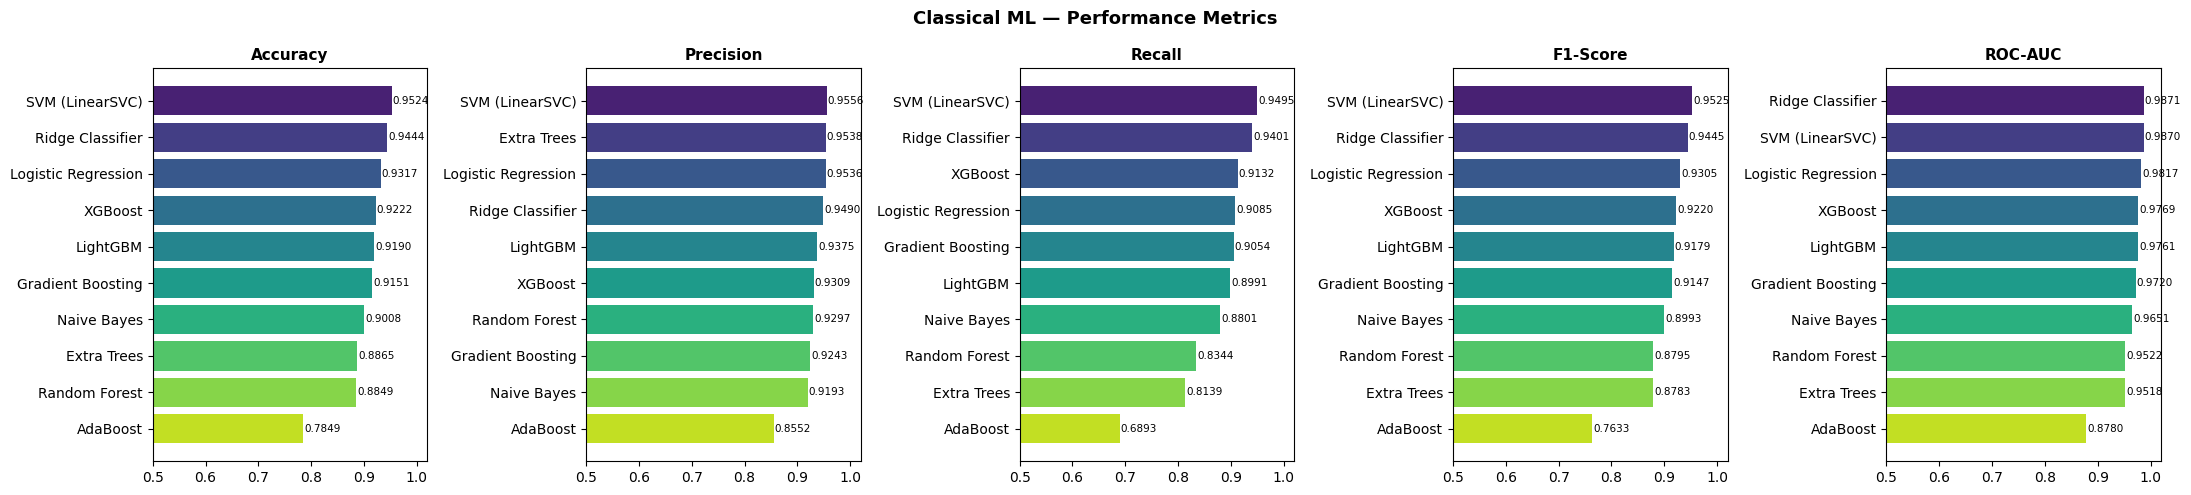

In [12]:
# Bar-chart comparison
plot_metrics = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
fig, axes    = plt.subplots(1, len(plot_metrics), figsize=(22, 5))
palette_bar  = sns.color_palette('viridis', len(df_classical))
for ax, metric in zip(axes, plot_metrics):
    sdf = df_classical[metric].sort_values(ascending=False)
    bars= ax.barh(sdf.index, sdf.values, color=palette_bar)
    ax.set_xlim(0.5, 1.02); ax.set_title(metric, fontsize=11, fontweight='bold')
    ax.invert_yaxis()
    for bar, val in zip(bars, sdf.values):
        ax.text(val+0.002, bar.get_y()+bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=7.5)
plt.suptitle('Classical ML — Performance Metrics', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


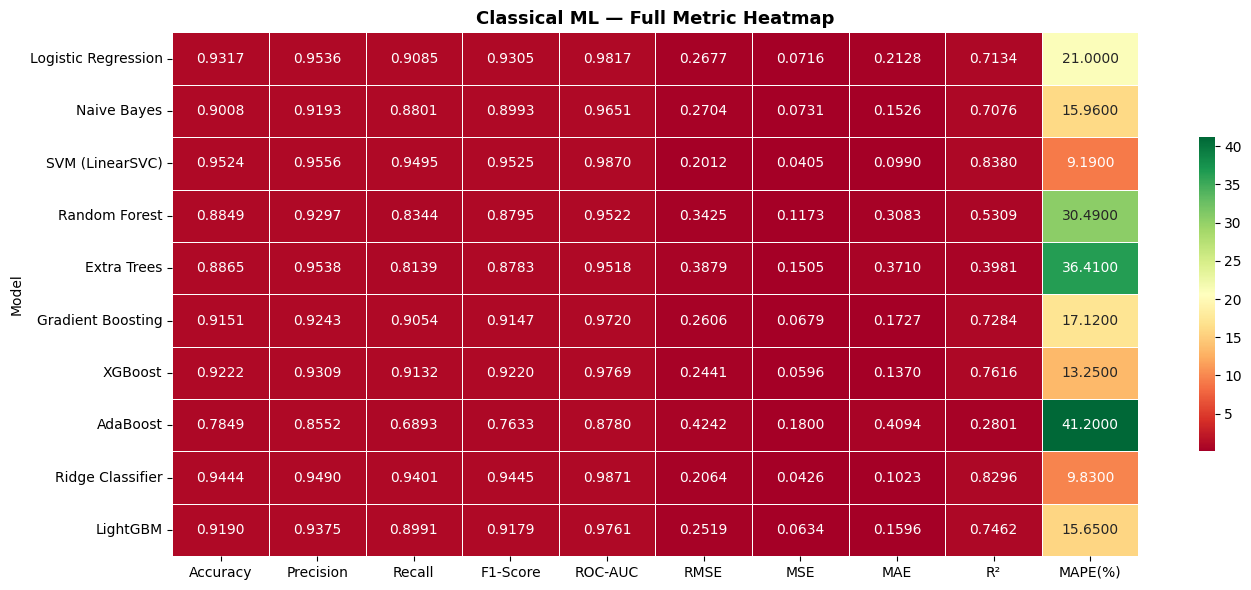

In [13]:
# Full metric heatmap
fig, ax = plt.subplots(figsize=(14, 6))
heat_data = df_classical[['Accuracy','Precision','Recall','F1-Score',
                           'ROC-AUC','RMSE','MSE','MAE','R²','MAPE(%)']]
sns.heatmap(heat_data, annot=True, fmt='.4f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, cbar_kws={'shrink': .6})
ax.set_title('Classical ML — Full Metric Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


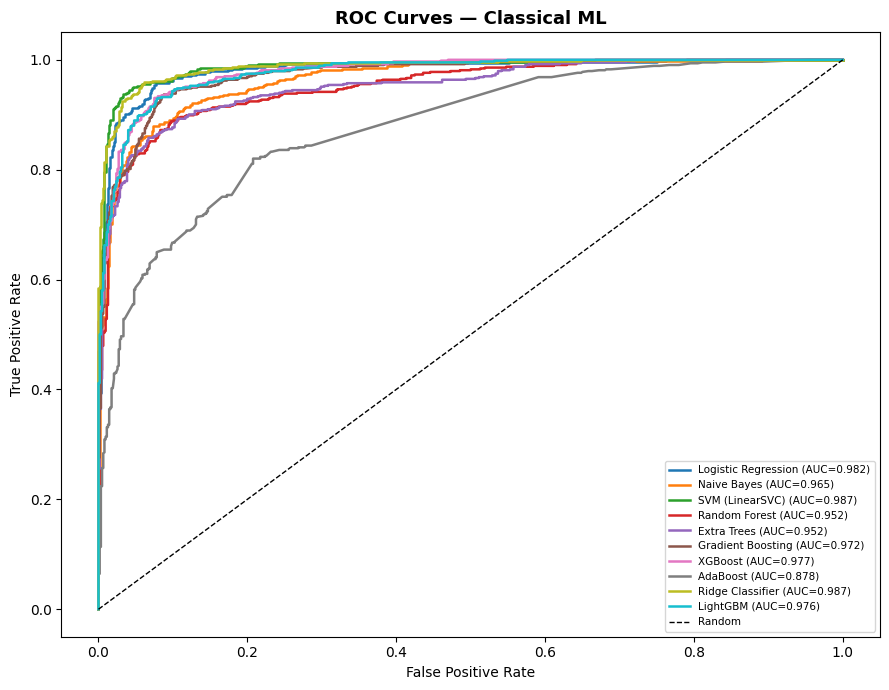

In [14]:
# ROC curves
fig, ax = plt.subplots(figsize=(9, 7))
colors  = plt.cm.tab10(np.linspace(0, 1, len(classical_models)))
for (name, clf), color in zip(classical_models.items(), colors):
    y_prob = clf.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})', color=color, lw=1.8)
ax.plot([0,1],[0,1],'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Classical ML', fontsize=13, fontweight='bold')
ax.legend(fontsize=7.5, loc='lower right'); plt.tight_layout(); plt.show()


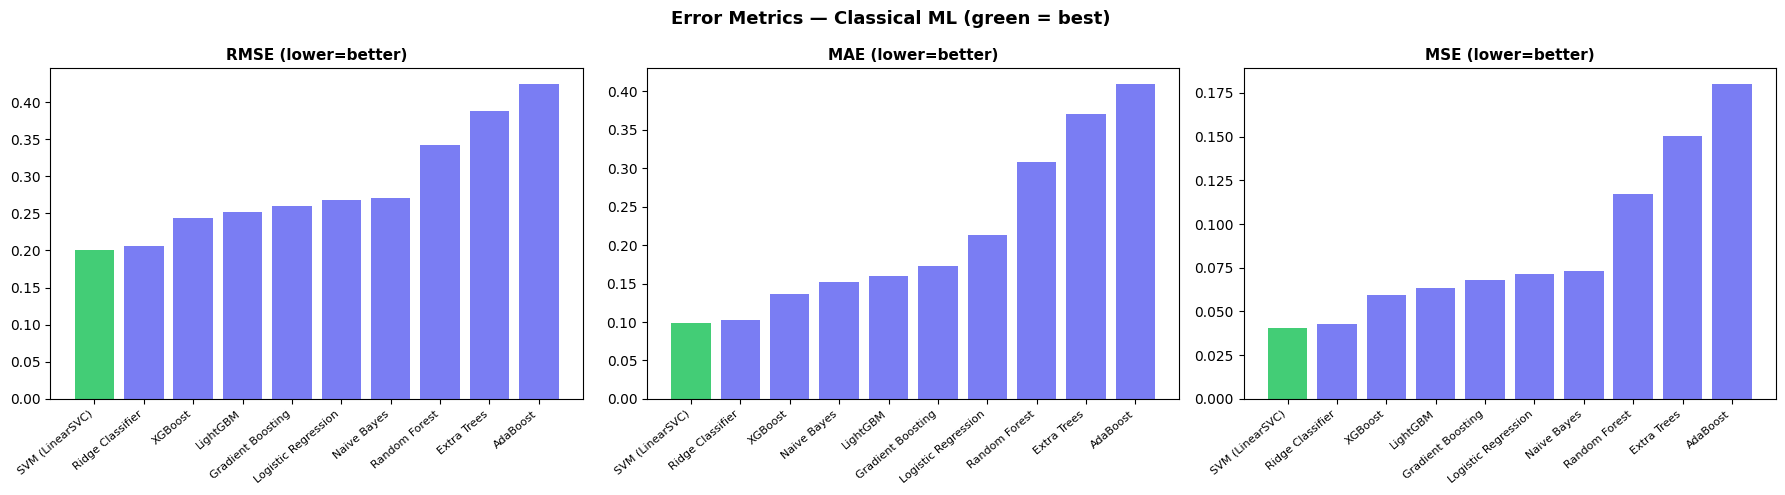

In [15]:
# Error metrics (RMSE, MAE, MSE) side-by-side
err_metrics = ['RMSE','MAE','MSE']
fig, axes   = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, err_metrics):
    sdf = df_classical[metric].sort_values()
    clrs= ['#22c55e' if v == sdf.min() else '#6366f1' for v in sdf.values]
    ax.bar(sdf.index, sdf.values, color=clrs, alpha=0.85)
    ax.set_title(f'{metric} (lower=better)', fontsize=11, fontweight='bold')
    ax.set_xticklabels(sdf.index, rotation=40, ha='right', fontsize=8)
plt.suptitle('Error Metrics — Classical ML (green = best)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


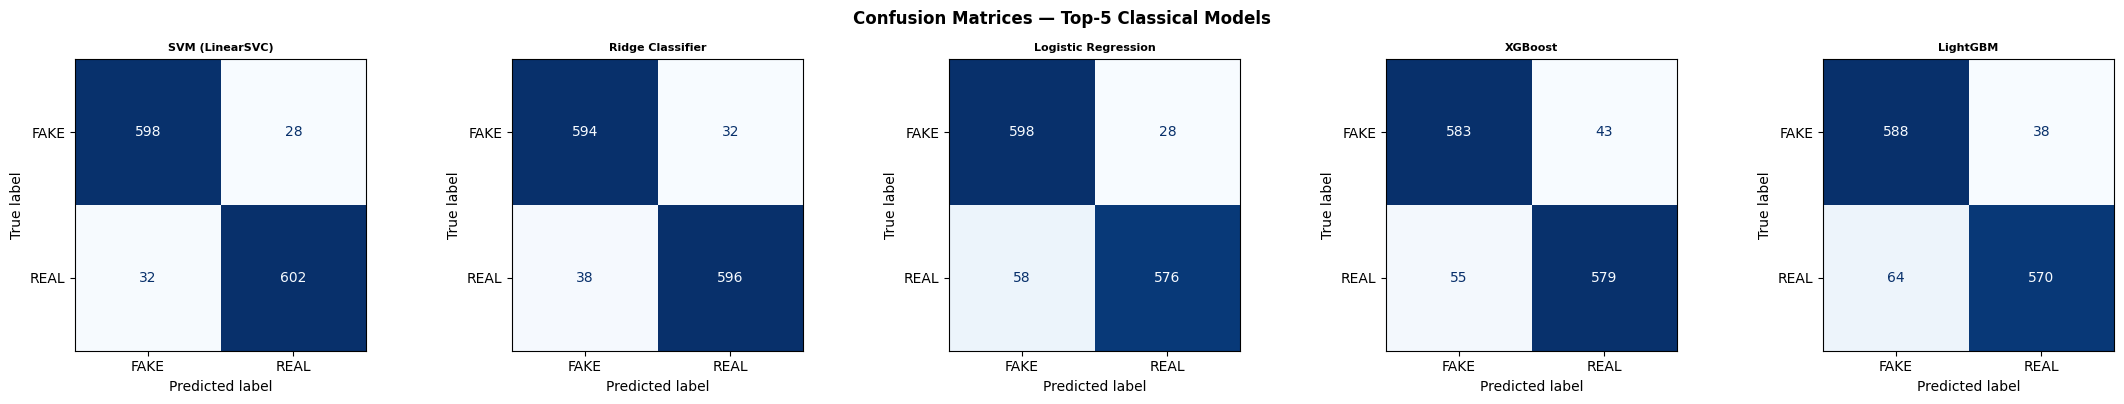

In [16]:
# Confusion matrices (top-5 by F1)
top5 = df_classical['F1-Score'].nlargest(5).index.tolist()
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, name in zip(axes, top5):
    clf    = classical_models[name]
    y_pred = clf.predict(X_te)
    cm     = confusion_matrix(y_te, y_pred)
    disp   = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=8, fontweight='bold')
plt.suptitle('Confusion Matrices — Top-5 Classical Models', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


## 5 · Deep Learning Models
> **Runtime note:** Run this section in **Google Colab with GPU**  
> (Runtime → Change runtime type → T4 GPU).  
> TensorFlow is required (`!pip install tensorflow`).


In [17]:
# Sequence data for DL
if HAS_TF:
    MAX_VOCAB   = 20_000
    MAX_SEQ_LEN = 300
    EMBED_DIM   = 128
    EPOCHS      = 8
    BATCH       = 128

    keras_tok = KerasTok(num_words=MAX_VOCAB, oov_token='<OOV>')
    keras_tok.fit_on_texts(df['clean'].tolist())
    seqs   = keras_tok.texts_to_sequences(df['clean'].tolist())
    X_seq  = pad_sequences(seqs, maxlen=MAX_SEQ_LEN, padding='post', truncating='post')

    X_seq_tr, X_seq_te, y_seq_tr, y_seq_te = train_test_split(
        X_seq, y, test_size=0.20, random_state=SEED, stratify=y)
    ES = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
    print(f'Sequence train: {X_seq_tr.shape}  test: {X_seq_te.shape}')
else:
    print('TensorFlow not available — skipping deep learning section.')


Sequence train: (5038, 300)  test: (1260, 300)


### 5.1 · Architecture Definitions

In [18]:
if HAS_TF:
    def build_textcnn():
        inp = Input(shape=(MAX_SEQ_LEN,))
        x   = Embedding(MAX_VOCAB, EMBED_DIM)(inp)
        branches = [GlobalMaxPooling1D()(Conv1D(128, k, activation='relu')(x))
                    for k in (2, 3, 5)]
        x = concatenate(branches)
        x = Dropout(0.4)(x)
        x = Dense(128, activation='relu')(x)
        x = Dropout(0.3)(x)
        out = Dense(1, activation='sigmoid')(x)
        m = Model(inp, out, name='TextCNN')
        m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        return m

    def build_lstm(bi=False):
        m = Sequential(name='BiLSTM' if bi else 'LSTM')
        m.add(Embedding(MAX_VOCAB, EMBED_DIM, input_length=MAX_SEQ_LEN))
        layer = LSTM(128, dropout=0.2, recurrent_dropout=0.2)
        m.add(Bidirectional(layer) if bi else layer)
        m.add(Dropout(0.3)); m.add(Dense(64, activation='relu'))
        m.add(Dense(1, activation='sigmoid'))
        m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        return m

    def build_gru(bi=False):
        m = Sequential(name='BiGRU' if bi else 'GRU')
        m.add(Embedding(MAX_VOCAB, EMBED_DIM, input_length=MAX_SEQ_LEN))
        layer = GRU(128, dropout=0.2, recurrent_dropout=0.2)
        m.add(Bidirectional(layer) if bi else layer)
        m.add(Dropout(0.3)); m.add(Dense(64, activation='relu'))
        m.add(Dense(1, activation='sigmoid'))
        m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        return m

    def build_cnn_lstm():
        m = Sequential(name='CNN_LSTM')
        m.add(Embedding(MAX_VOCAB, EMBED_DIM, input_length=MAX_SEQ_LEN))
        m.add(Conv1D(128, 3, activation='relu'))
        m.add(LSTM(128, dropout=0.2))
        m.add(Dropout(0.3)); m.add(Dense(64, activation='relu'))
        m.add(Dense(1, activation='sigmoid'))
        m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        return m

    def build_deep_mlp():
        m = Sequential(name='DeepMLP_Word2Vec')
        m.add(Embedding(MAX_VOCAB, EMBED_DIM, input_length=MAX_SEQ_LEN))
        m.add(GlobalMaxPooling1D())
        m.add(Dense(512, activation='relu')); m.add(Dropout(0.4))
        m.add(Dense(256, activation='relu')); m.add(Dropout(0.3))
        m.add(Dense(128, activation='relu')); m.add(Dropout(0.2))
        m.add(Dense(1, activation='sigmoid'))
        m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        return m

    dl_specs = [
        ('TextCNN',             build_textcnn),
        ('LSTM',                build_lstm),
        ('Bidirectional LSTM',  lambda: build_lstm(bi=True)),
        ('GRU',                 build_gru),
        ('Bidirectional GRU',   lambda: build_gru(bi=True)),
        ('CNN-LSTM Hybrid',     build_cnn_lstm),
        ('Deep MLP (Word2Vec)', build_deep_mlp),
    ]
    print(f'{len(dl_specs)} DL architectures defined ✓')


7 DL architectures defined ✓


### 5.2 · Training Deep Learning Models

In [19]:
if HAS_TF:
    results_dl = []
    trained_dl = {}

    for name, builder in dl_specs:
        print(f'\n  Training {name} ...', flush=True)
        t0  = time.time()
        mdl = builder()
        hist = mdl.fit(
            X_seq_tr, y_seq_tr,
            validation_split=0.1,
            epochs=EPOCHS,
            batch_size=BATCH,
            callbacks=[ES],
            verbose=1
        )
        elapsed = time.time() - t0
        y_prob = mdl.predict(X_seq_te, verbose=0).flatten()
        y_pred = (y_prob >= 0.5).astype(int)
        m = compute_all_metrics(name, y_seq_te, y_pred, y_prob, elapsed)
        results_dl.append(m)
        trained_dl[name] = (mdl, hist)
        print(f"  Acc={m['Accuracy']:.4f}  F1={m['F1-Score']:.4f}  "
              f"ROC-AUC={m['ROC-AUC']:.4f}  ({elapsed:.1f}s)")

    df_dl = pd.DataFrame(results_dl).set_index('Model')
    df_dl.rename(columns={'R2': 'R²'}, inplace=True)
    print('\n✓ All DL models trained.')
else:
    print('Skipped — TensorFlow not available.')



  Training TextCNN ...
Epoch 1/8
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 170ms/step - accuracy: 0.6045 - loss: 0.6579 - val_accuracy: 0.7679 - val_loss: 0.5402
Epoch 2/8
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8139 - loss: 0.4236 - val_accuracy: 0.8770 - val_loss: 0.2914
Epoch 3/8
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9082 - loss: 0.2392 - val_accuracy: 0.9028 - val_loss: 0.2171
Epoch 4/8
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9629 - loss: 0.1193 - val_accuracy: 0.9187 - val_loss: 0.1970
Epoch 5/8
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9843 - loss: 0.0564 - val_accuracy: 0.9226 - val_loss: 0.1854
Epoch 6/8
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9940 - loss: 0.0250 - val_accuracy: 0.9306 - val_loss: 0.1831
Epoch 7/8
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9987 - loss: 0.0123 - val_accuracy: 0.9464 - val_loss: 0.1768
Epoch 8/8
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9985 - loss: 0.0078 - val_ac

In [20]:
if HAS_TF:
    display_cols = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC',
                    'RMSE','MSE','MAE','R²','MAPE(%)','Time(s)']
    styled_dl = (df_dl[display_cols]
        .style
        .background_gradient(cmap='YlGn',
            subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC','R²'])
        .background_gradient(cmap='YlOrRd_r',
            subset=['RMSE','MSE','MAE','MAPE(%)'])
        .format('{:.4f}', subset=['Accuracy','Precision','Recall','F1-Score',
                                   'ROC-AUC','RMSE','MSE','MAE','R²'])
        .format('{:.2f}', subset=['MAPE(%)','Time(s)'])
        .set_caption('Deep Learning — Full Metrics (10 metrics)'))
    display(styled_dl)
else:
    print('No DL results — TensorFlow not installed.')


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,RMSE,MSE,MAE,R²,MAPE(%),Time(s)
Model,,,,,,,,,,,
TextCNN,0.9333,0.9283,0.9401,0.9342,0.9824,0.2177,0.0474,0.0791,0.8104,6.83,19.79
LSTM,0.7056,0.7240,0.6703,0.6962,0.7450,0.4712,0.2221,0.4600,0.1117,48.95,80.87
Bidirectional LSTM,0.8913,0.8976,0.8849,0.8912,0.9561,0.2855,0.0815,0.1918,0.6740,19.28,133.40
GRU,0.6071,0.5739,0.8517,0.6857,0.6769,0.4832,0.2334,0.4693,0.0662,43.91,68.65
Bidirectional GRU,0.8706,0.8720,0.8707,0.8713,0.9425,0.3107,0.0965,0.2216,0.6138,21.24,122.74
CNN-LSTM Hybrid,0.6365,0.6007,0.8281,0.6963,0.7318,0.4694,0.2203,0.4509,0.1187,42.77,5.22
Deep MLP (Word2Vec),0.6071,0.5739,0.8517,0.6857,0.8393,0.4725,0.2232,0.4509,0.1070,41.08,8.65


### 5.3 · Deep Learning Training Curves & ROC

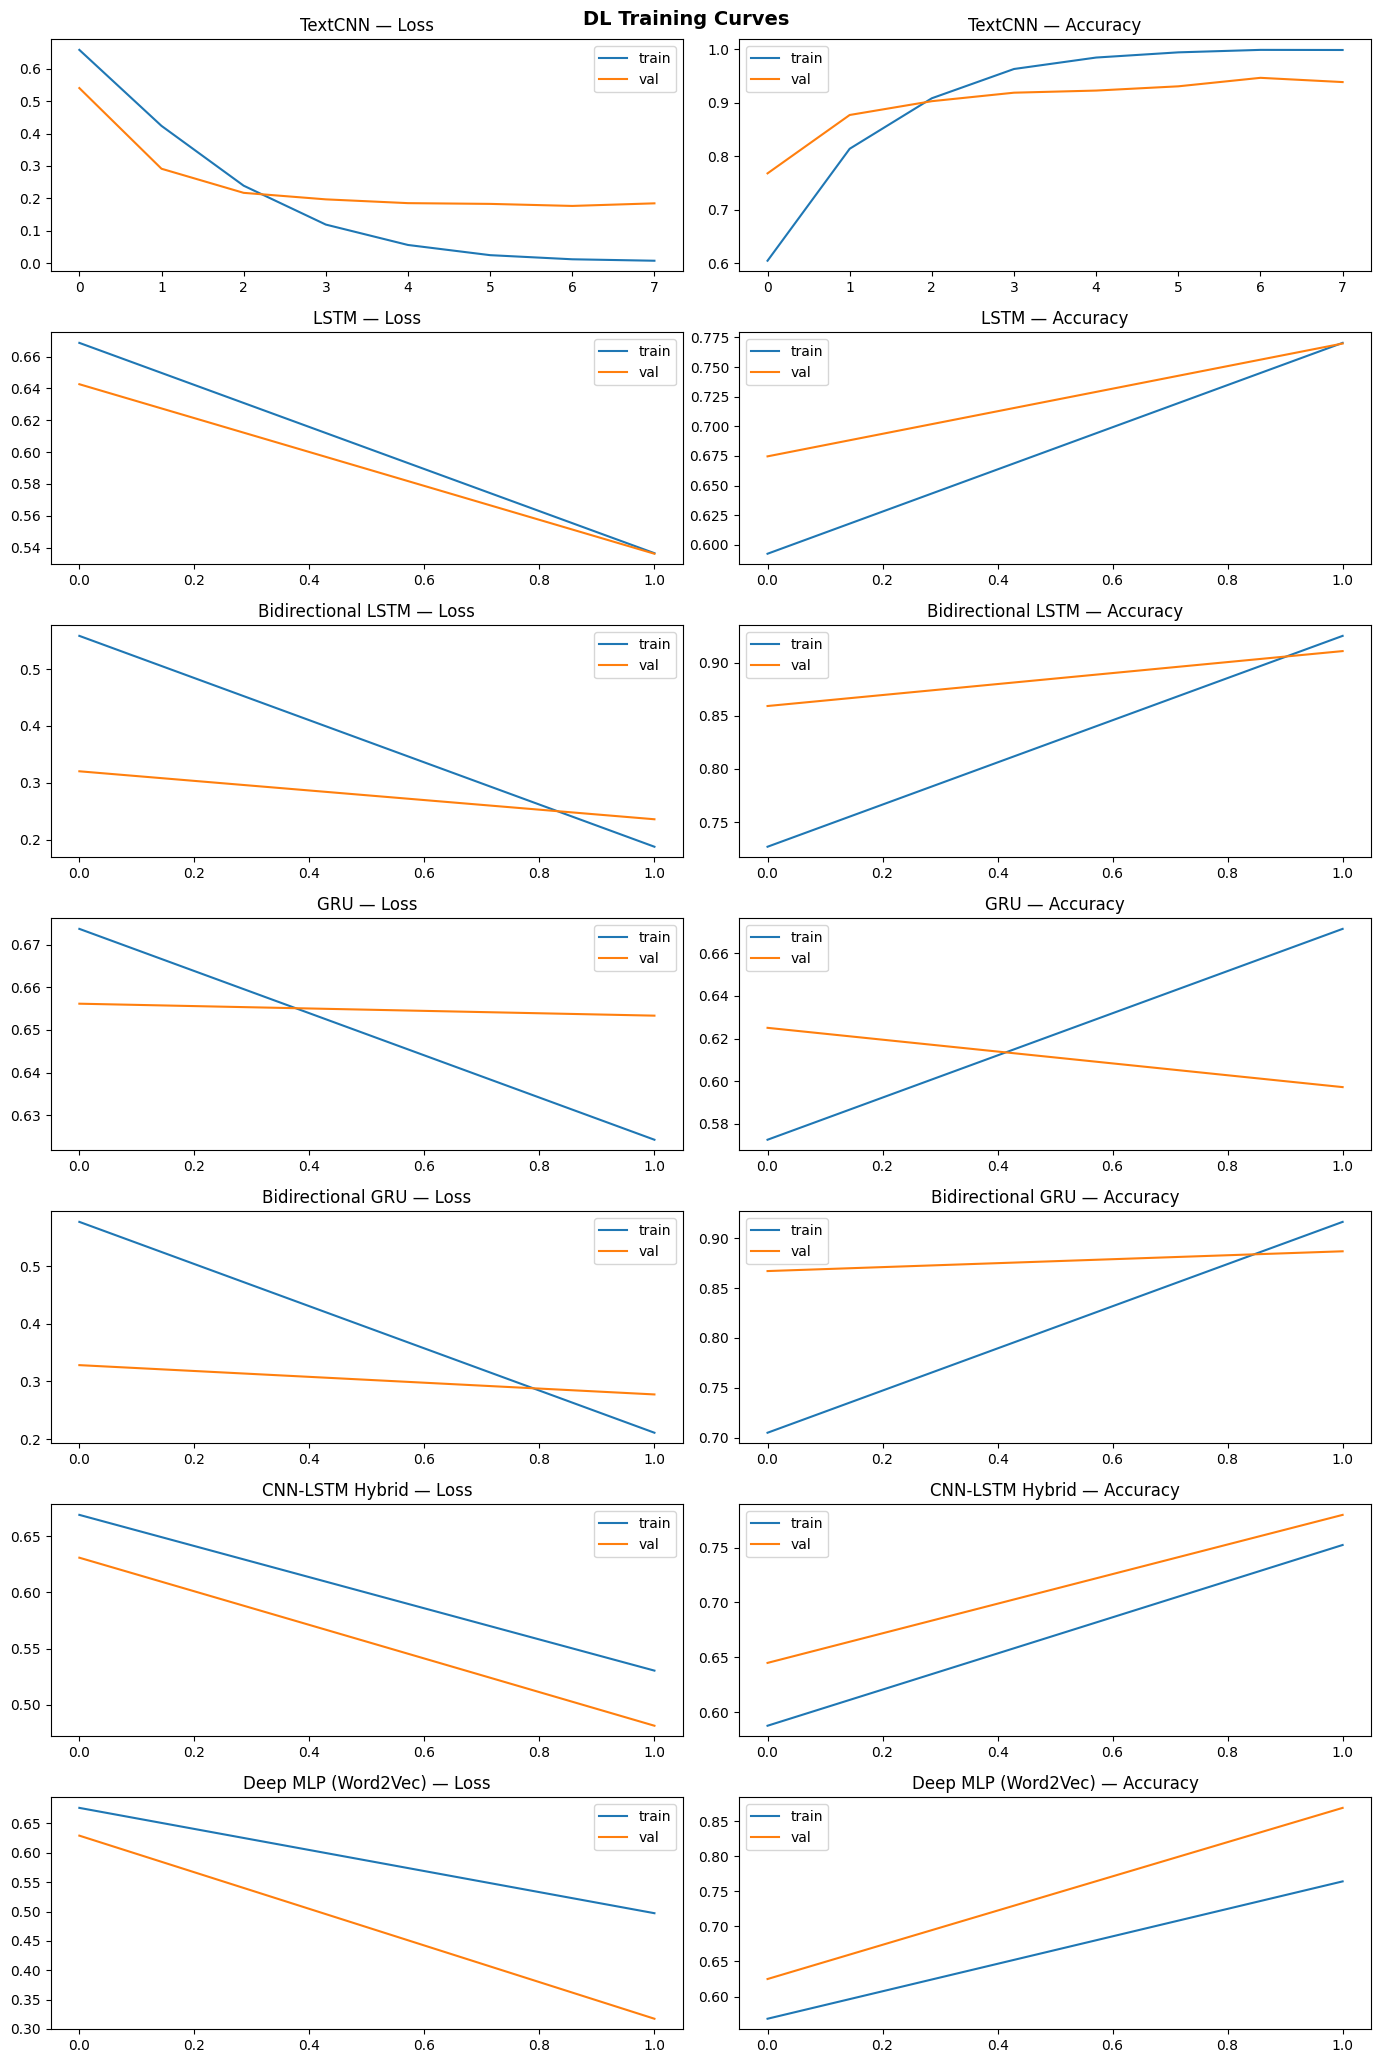

In [21]:
if HAS_TF:
    n = len(trained_dl)
    fig, axes = plt.subplots(n, 2, figsize=(14, n * 3))
    for i, (name, (mdl, hist)) in enumerate(trained_dl.items()):
        axes[i,0].plot(hist.history['loss'],     label='train')
        axes[i,0].plot(hist.history['val_loss'], label='val')
        axes[i,0].set_title(f'{name} — Loss'); axes[i,0].legend()
        axes[i,1].plot(hist.history['accuracy'],     label='train')
        axes[i,1].plot(hist.history['val_accuracy'], label='val')
        axes[i,1].set_title(f'{name} — Accuracy'); axes[i,1].legend()
    plt.suptitle('DL Training Curves', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()


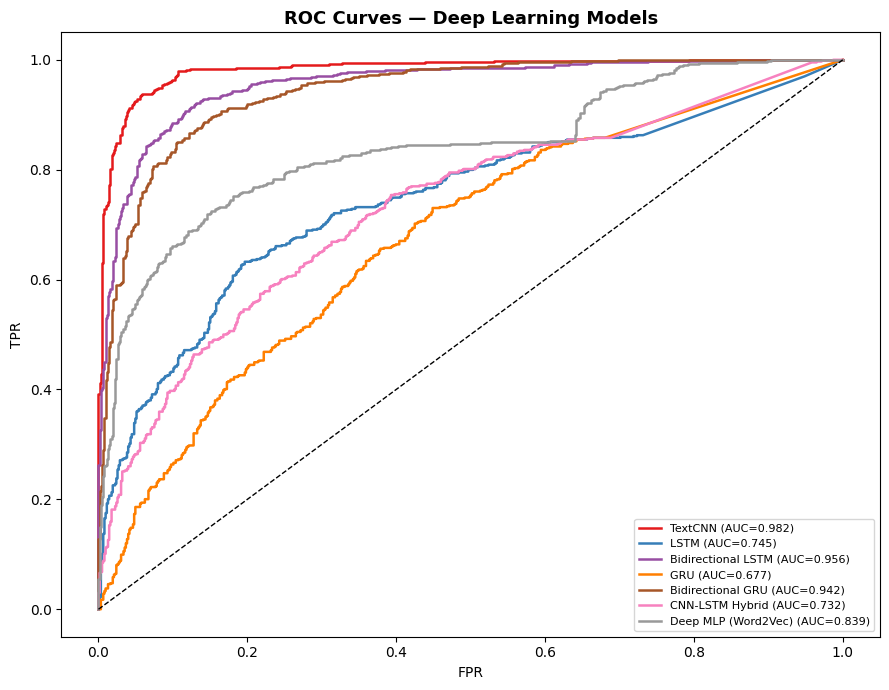

In [22]:
if HAS_TF:
    fig, ax = plt.subplots(figsize=(9, 7))
    colors  = plt.cm.Set1(np.linspace(0, 1, len(trained_dl)))
    for (name, (mdl, _)), color in zip(trained_dl.items(), colors):
        y_prob = mdl.predict(X_seq_te, verbose=0).flatten()
        fpr, tpr, _ = roc_curve(y_seq_te, y_prob)
        ax.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr,tpr):.3f})', color=color, lw=1.8)
    ax.plot([0,1],[0,1],'k--', lw=1)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title('ROC Curves — Deep Learning Models', fontsize=13, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right'); plt.tight_layout(); plt.show()


## 6 · Combined Comparison: All 17 Models

In [23]:
all_frames = [df_classical.reset_index()]
if HAS_TF and 'df_dl' in dir():
    all_frames.append(df_dl.reset_index())

df_all = pd.concat(all_frames, ignore_index=True).set_index('Model')
print(f'Total models in comparison: {len(df_all)}')

display_cols = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC',
                'RMSE','MSE','MAE','R²','MAPE(%)','Time(s)']

styled_all = (df_all[display_cols]
    .style
    .background_gradient(cmap='YlGn',
        subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC','R²'])
    .background_gradient(cmap='YlOrRd_r',
        subset=['RMSE','MSE','MAE','MAPE(%)'])
    .format('{:.4f}', subset=['Accuracy','Precision','Recall','F1-Score',
                               'ROC-AUC','RMSE','MSE','MAE','R²'])
    .format('{:.2f}', subset=['MAPE(%)','Time(s)'])
    .set_caption('ALL MODELS — Complete Metric Comparison')
    .highlight_max(subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC','R²'],
                   color='#bbf7d0')
    .highlight_min(subset=['RMSE','MSE','MAE','MAPE(%)'],
                   color='#bbf7d0'))
display(styled_all)


Total models in comparison: 17


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,RMSE,MSE,MAE,R²,MAPE(%),Time(s)
Model,,,,,,,,,,,
Logistic Regression,0.9317,0.9536,0.9085,0.9305,0.9817,0.2677,0.0716,0.2128,0.7134,21.00,0.21
Naive Bayes,0.9008,0.9193,0.8801,0.8993,0.9651,0.2704,0.0731,0.1526,0.7076,15.96,0.01
SVM (LinearSVC),0.9524,0.9556,0.9495,0.9525,0.9870,0.2012,0.0405,0.0990,0.8380,9.19,0.45
Random Forest,0.8849,0.9297,0.8344,0.8795,0.9522,0.3425,0.1173,0.3083,0.5309,30.49,6.43
Extra Trees,0.8865,0.9538,0.8139,0.8783,0.9518,0.3879,0.1505,0.3710,0.3981,36.41,3.82
Gradient Boosting,0.9151,0.9243,0.9054,0.9147,0.9720,0.2606,0.0679,0.1727,0.7284,17.12,153.31
XGBoost,0.9222,0.9309,0.9132,0.9220,0.9769,0.2441,0.0596,0.1370,0.7616,13.25,108.46
AdaBoost,0.7849,0.8552,0.6893,0.7633,0.8780,0.4242,0.1800,0.4094,0.2801,41.20,42.17
Ridge Classifier,0.9444,0.9490,0.9401,0.9445,0.9871,0.2064,0.0426,0.1023,0.8296,9.83,0.59


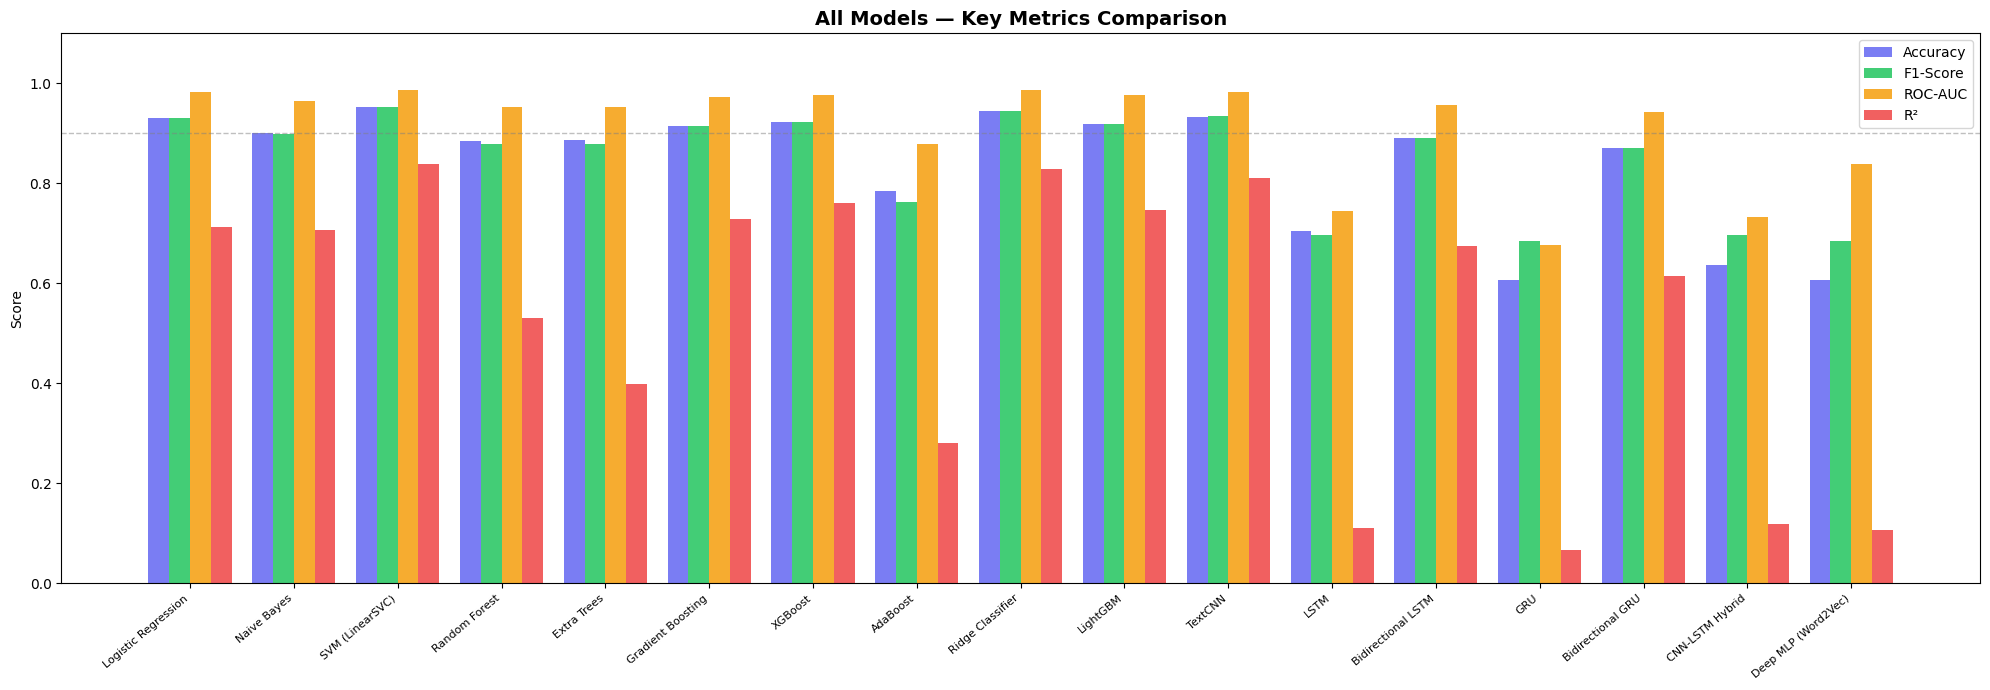

In [24]:
# Grouped bar chart: all models x key metrics
key_metrics = ['Accuracy','F1-Score','ROC-AUC','R²']
fig, ax = plt.subplots(figsize=(20, 7))
x  = np.arange(len(df_all))
w  = 0.2
colors_m = ['#6366f1','#22c55e','#f59e0b','#ef4444']
for i, (metric, color) in enumerate(zip(key_metrics, colors_m)):
    ax.bar(x + i*w - w*1.5, df_all[metric].values, w,
           label=metric, color=color, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(df_all.index, rotation=40, ha='right', fontsize=8)
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title('All Models — Key Metrics Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.axhline(0.9, ls='--', color='gray', alpha=0.5, lw=1)
plt.tight_layout(); plt.show()


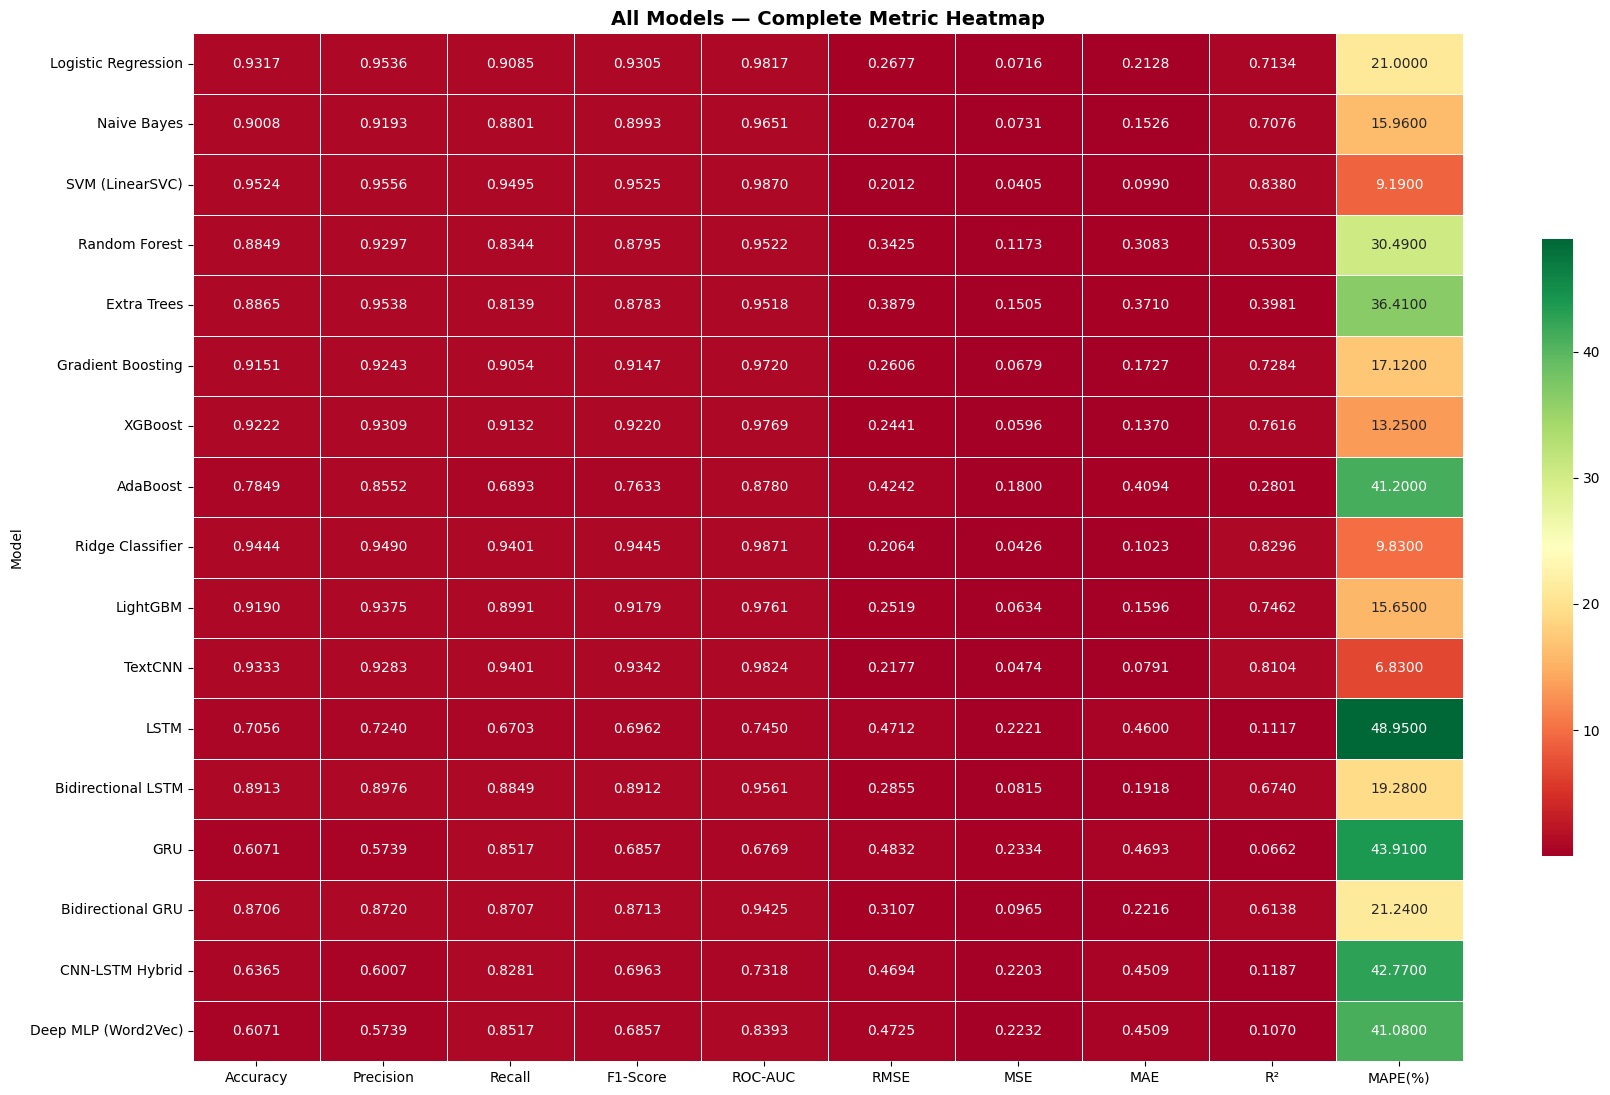

In [25]:
# Complete heatmap — all models
fig, ax = plt.subplots(figsize=(18, max(6, len(df_all)*0.65)))
heat_cols = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC',
             'RMSE','MSE','MAE','R²','MAPE(%)']
sns.heatmap(df_all[heat_cols], annot=True, fmt='.4f',
            cmap='RdYlGn', linewidths=0.4, ax=ax,
            cbar_kws={'shrink': 0.6})
ax.set_title('All Models — Complete Metric Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


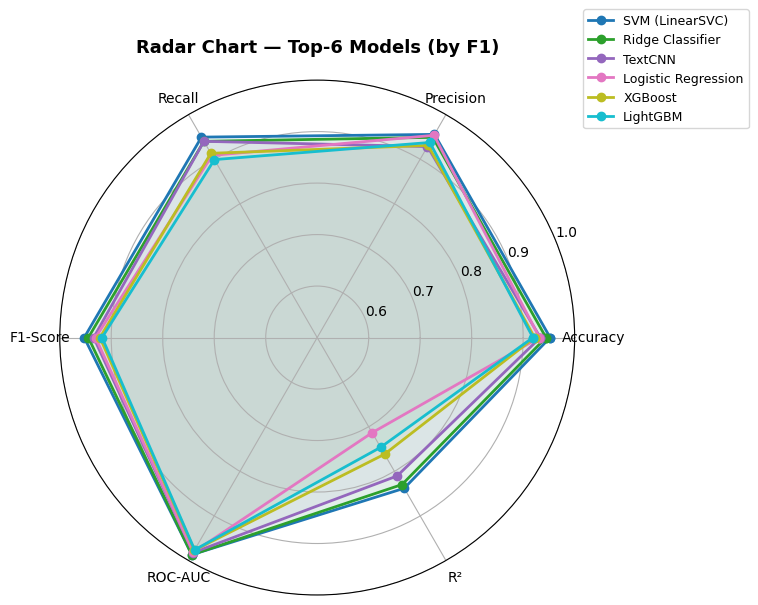

In [26]:
# Radar chart — top 6 models by F1
top6         = df_all['F1-Score'].nlargest(6).index.tolist()
radar_metrics= ['Accuracy','Precision','Recall','F1-Score','ROC-AUC','R²']
angles = np.linspace(0, 2*np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors_r = plt.cm.tab10(np.linspace(0, 1, 6))
for model, color in zip(top6, colors_r):
    vals  = df_all.loc[model, radar_metrics].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', lw=2, label=model, color=color)
    ax.fill(angles, vals, alpha=0.07, color=color)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(radar_metrics, fontsize=10)
ax.set_ylim(0.5, 1.0)
ax.set_title('Radar Chart — Top-6 Models (by F1)', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout(); plt.show()


## 7 · Model Leaderboard & Best Model Summary

In [27]:
# Composite ranking: rank each metric, average
higher_better = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC','R²']
lower_better  = ['RMSE','MSE','MAE','MAPE(%)']

rank_df = pd.DataFrame(index=df_all.index)
for col in higher_better:
    rank_df[col] = df_all[col].rank(ascending=False)
for col in lower_better:
    rank_df[col] = df_all[col].rank(ascending=True)
rank_df['Avg Rank'] = rank_df.mean(axis=1)
rank_df = rank_df.sort_values('Avg Rank')

print('=' * 58)
print('   MODEL LEADERBOARD  (lower avg rank = better overall)')
print('=' * 58)
for i, (model, row) in enumerate(rank_df.iterrows(), 1):
    medal = '🥇' if i==1 else '🥈' if i==2 else '🥉' if i==3 else f'#{i} '
    print(f' {medal}  {model:<30}  Avg Rank: {row["Avg Rank"]:.2f}')
print('=' * 58)


   MODEL LEADERBOARD  (lower avg rank = better overall)
 🥇  SVM (LinearSVC)                 Avg Rank: 1.30
 🥈  Ridge Classifier                Avg Rank: 2.35
 🥉  TextCNN                         Avg Rank: 3.05
 #4   XGBoost                         Avg Rank: 4.50
 #5   LightGBM                        Avg Rank: 5.60
 #6   Logistic Regression             Avg Rank: 5.90
 #7   Gradient Boosting               Avg Rank: 6.80
 #8   Naive Bayes                     Avg Rank: 7.80
 #9   Bidirectional LSTM              Avg Rank: 8.90
 #10   Random Forest                   Avg Rank: 10.60
 #11   Bidirectional GRU               Avg Rank: 10.80
 #12   Extra Trees                     Avg Rank: 10.90
 #13   AdaBoost                        Avg Rank: 13.40
 #14   CNN-LSTM Hybrid                 Avg Rank: 14.55
 #15   Deep MLP (Word2Vec)             Avg Rank: 15.05
 #16   LSTM                            Avg Rank: 15.30
 #17   GRU                             Avg Rank: 16.20


In [28]:
# Full ranking table (styled)
rank_display = rank_df.copy()
for c in higher_better + lower_better:
    rank_display[c] = rank_display[c].astype(int)
rank_display['Avg Rank'] = rank_display['Avg Rank'].round(2)
display(rank_display.style
    .background_gradient(cmap='YlGn_r', subset=['Avg Rank'])
    .set_caption('Metric-Rank Leaderboard (1 = best per metric)'))


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,R²,RMSE,MSE,MAE,MAPE(%),Avg Rank
Model,,,,,,,,,,,
SVM (LinearSVC),1,1,1,1,2,1,1,1,2,2,1.300000
Ridge Classifier,2,4,2,2,1,2,2,2,3,3,2.350000
TextCNN,3,8,2,3,3,3,3,3,1,1,3.050000
XGBoost,5,6,4,5,5,4,4,4,4,4,4.500000
LightGBM,6,5,7,6,6,5,5,5,6,5,5.600000
Logistic Regression,4,3,5,4,4,7,7,7,9,9,5.900000
Gradient Boosting,7,9,6,7,7,6,6,6,7,7,6.800000
Naive Bayes,8,10,9,8,8,8,8,8,5,6,7.800000
Bidirectional LSTM,9,11,8,9,9,9,9,9,8,8,8.900000


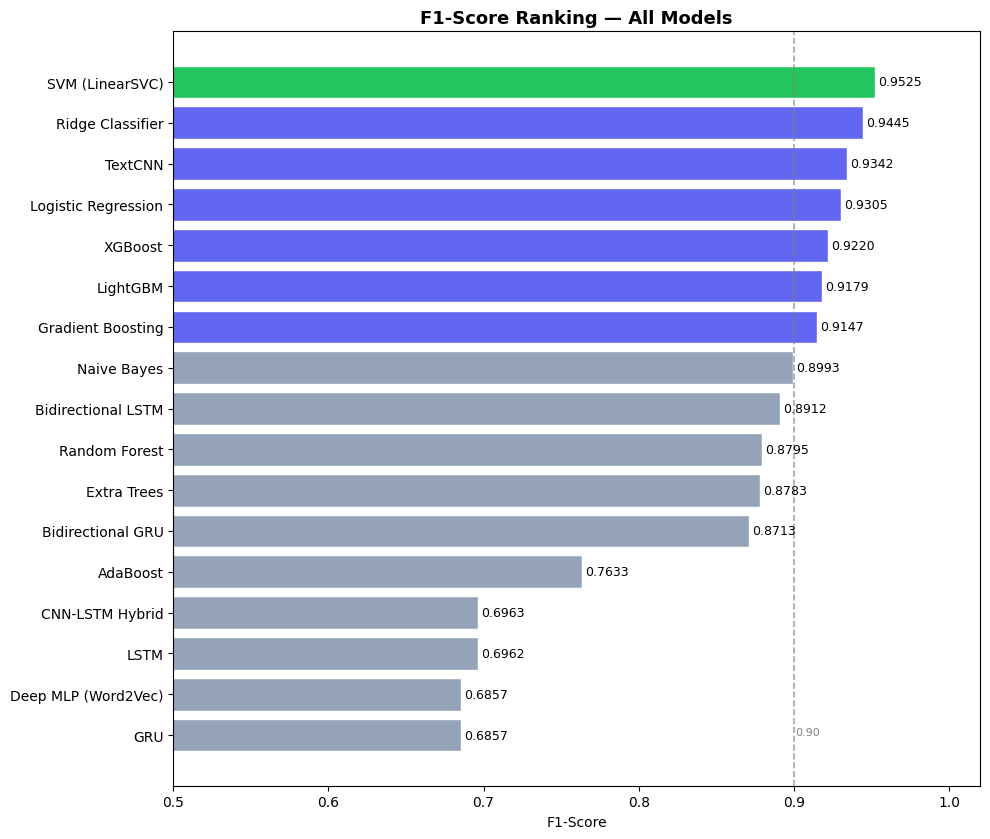

In [29]:
# F1 horizontal ranking bar chart
f1_sorted = df_all['F1-Score'].sort_values(ascending=True)
colors_f1 = ['#22c55e' if v == f1_sorted.max()
             else '#6366f1' if v >= 0.90 else '#94a3b8'
             for v in f1_sorted.values]
fig, ax = plt.subplots(figsize=(10, max(5, len(f1_sorted)*0.5)))
bars = ax.barh(f1_sorted.index, f1_sorted.values, color=colors_f1, edgecolor='white')
ax.set_xlim(0.5, 1.02)
ax.axvline(0.90, ls='--', color='gray', alpha=0.7, lw=1.2)
ax.text(0.901, 0, '0.90', color='gray', fontsize=8)
for bar, val in zip(bars, f1_sorted.values):
    ax.text(val+0.002, bar.get_y()+bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_xlabel('F1-Score')
ax.set_title('F1-Score Ranking — All Models', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


In [30]:
# Best model summary card
best_model = rank_df.index[0]
best_row   = df_all.loc[best_model]
print(f'\n{"="*52}')
print(f'  🏆  BEST OVERALL MODEL: {best_model}')
print(f'{"="*52}')
for metric in ['Accuracy','Precision','Recall','F1-Score','ROC-AUC',
               'RMSE','MSE','MAE','R²','MAPE(%)']:
    val = best_row[metric]
    print(f'  {metric:<15}: {val:.4f}')
print(f'{"="*52}')



  🏆  BEST OVERALL MODEL: SVM (LinearSVC)
  Accuracy       : 0.9524
  Precision      : 0.9556
  Recall         : 0.9495
  F1-Score       : 0.9525
  ROC-AUC        : 0.9870
  RMSE           : 0.2012
  MSE            : 0.0405
  MAE            : 0.0990
  R²             : 0.8380
  MAPE(%)        : 9.1900


## 8 · Export Results

In [31]:
out_path = 'fake_news_all_model_metrics.csv'
df_all[display_cols].reset_index().to_csv(out_path, index=False)
print(f"Saved to '{out_path}'")

print('\n' + '='*100)
print('FINAL SUMMARY — ALL MODELS')
print('='*100)
col_w  = [28,9,9,9,9,9,9,8,8,8,9]
header = ['Model','Accuracy','Precision','Recall','F1-Score','ROC-AUC','RMSE','MSE','MAE','R²','MAPE(%)']
fmt    = ''.join(f'{{:<{w}}}' for w in col_w)
print(fmt.format(*header))
print('-'*100)
for model, row in df_all.sort_values('Accuracy', ascending=False).iterrows():
    vals = [model,
            f"{row['Accuracy']:.4f}", f"{row['Precision']:.4f}",
            f"{row['Recall']:.4f}",   f"{row['F1-Score']:.4f}",
            f"{row['ROC-AUC']:.4f}",  f"{row['RMSE']:.4f}",
            f"{row['MSE']:.4f}",      f"{row['MAE']:.4f}",
            f"{row['R²']:.4f}",       f"{row['MAPE(%)']:.2f}"]
    print(fmt.format(*vals))
print('='*100)


Saved to 'fake_news_all_model_metrics.csv'

FINAL SUMMARY — ALL MODELS
Model                       Accuracy PrecisionRecall   F1-Score ROC-AUC  RMSE     MSE     MAE     R²      MAPE(%)  
----------------------------------------------------------------------------------------------------
SVM (LinearSVC)             0.9524   0.9556   0.9495   0.9525   0.9870   0.2012   0.0405  0.0990  0.8380  9.19     
Ridge Classifier            0.9444   0.9490   0.9401   0.9445   0.9871   0.2064   0.0426  0.1023  0.8296  9.83     
TextCNN                     0.9333   0.9283   0.9401   0.9342   0.9824   0.2177   0.0474  0.0791  0.8104  6.83     
Logistic Regression         0.9317   0.9536   0.9085   0.9305   0.9817   0.2677   0.0716  0.2128  0.7134  21.00    
XGBoost                     0.9222   0.9309   0.9132   0.9220   0.9769   0.2441   0.0596  0.1370  0.7616  13.25    
LightGBM                    0.9190   0.9375   0.8991   0.9179   0.9761   0.2519   0.0634  0.1596  0.7462  15.65    
Gradient Boostin